# Beispiel Projekt "Wetteranalyse in Städten unterschiedlicher Länder"

In [1]:
# !pip install geonamescache
import geonamescache
import pandas as pd
import seaborn as sns
import requests

## Projekt Idee

Grosse Projekt Idee:

"Ich möchte von allen europäischen Städten umfassende Informationen über die Bevölkerung und das dazugehörige Wetter sammeln und analysieren. Die gesammelten Daten sollen sowohl zur Identifizierung von Trends als auch zur Visualisierung verwendet werden, um ein besseres Verständnis der städtischen Struktur und der klimatischen Bedingungen in gewissen Regionen Europas zu erhalten."

## Idee Aufteilen

Kleinere Aufgaben:
- Nutze verfügbare Bibliotheken und Datenquellen, um Informationen über europäische Städte zu sammeln, die eine bestimmte Einwohnergrenze überschreiten, um die Ergebnisliste auf einen handhabbaren Umfang zu beschränken.
- Überlege, welche Länder und Städte am relevantesten für dich sein könnten, und wie viele Datenpunkte für eine sinnvolle Visualisierung von monatlichen Durchschnittstemperaturen erforderlich wären. Sammle und integriere die Wetterdaten entsprechend und erstelle eine umfassende Analyse und Visualisierung.

## Aufgabe 1.0



Nutze die geonamescache-Bibliothek und pandas, um alle Städte in Europa mit mehr als 10.000 Einwohnern zu identifizieren und diese in eine CSV-Datei zu speichern. Ein kluger Ansatz wäre es, die Daten der Städte und Länder zu kombinieren, sodass du den continentcode jeder Stadt direkt abrufen kannst.

Zerlege das problem erst in einzelne Schritte und schreibe eine Vorgehensweise auf

## Vorgehensweise

**Datenextraktion**:
- Hole mit Hilfe der geonamescache-Bibliothek die Daten aller Länder und Städte.
- Konvertiere diese Daten in separate Pandas DataFrames.

**Datenkombination**:
- Führe die DataFrames von Städten und Ländern zusammen, indem du einen passenden Schlüssel (z.B. Ländercode) verwendest, um den continentcode jeder Stadt hinzuzufügen.
- Überlege, welche Spalten für die Kombination wichtig sind und wie du redundante Spalten vermeiden kannst.

**Datenfilterung**:
- Filtere die Daten so, dass du nur Städte aus Europa (continentcode = 'EU') mit mehr als 10.000 Einwohnern behältst.

**CSV-Speicherung**:
- Speichere das resultierende DataFrame in einer CSV-Datei.

**Tipps**:
- Versuche, deinen Code modular zu gestalten, vielleicht durch die Nutzung von Funktionen.
- Kommentiere deinen Code und nutze bei Bedarf Docstrings, damit du (und andere) den Prozess leichter nachvollziehen können.

In [2]:
def get_countries_cities():
    """
    Extrahiert Länder- und Städteinformationen mittels der geonamescache-Bibliothek.

    Returns:
        df_countries (pd.DataFrame): DataFrame mit Länderinformationen.
        df_cities (pd.DataFrame): DataFrame mit Städteinformationen, erweitert um den zugehörigen Kontinentcode.
    """

    # Initialisierung von geonamescache
    gc = geonamescache.GeonamesCache()

    # Länderinformationen extrahieren und in DataFrame konvertieren
    countries = gc.get_countries()
    df_countries = pd.DataFrame(countries.values())

    # Städteinformationen extrahieren und in DataFrame konvertieren
    cities = gc.get_cities()

    # Kombinieren der Städteinformationen mit dem Kontinentcode aus den Länderinformationen
    df_cities = (
        pd.DataFrame(cities.values()).merge(
            # Auswählen der relevanten Spalten zum Zusammenführen
            df_countries[["iso", "continentcode"]],
            left_on="countrycode",  # Schlüsselspalte im Städte-DataFrame
            right_on="iso",  # Schlüsselspalte im Länder-DataFrame
            how="left",  # Typ des Zusammenführungsprozesses
        )
        # Entfernen der redundanten 'iso'-Spalte nach dem Zusammenführen
        .drop(columns=["iso"])
    )

    return df_countries, df_cities


# Funktion aufrufen und Ergebnisse in DataFrames speichern
df_countries, df_cities = get_countries_cities()

### Code Kommentar

Das obige Beispiel demonstriert eine klare und methodische Herangehensweise an das Problem der Datenextraktion und -kombination mithilfe der geonamescache-Bibliothek und pandas.

**Klarheit und Zweckmässigkeit**: Der Code beginnt mit der Definition einer Funktion, get_countries_cities, die speziell darauf ausgerichtet ist, Länder- und Städteinformationen zu extrahieren. Ein Docstring gibt eine klare Definition dessen, was die Funktion macht und welche Ausgaben zu erwarten sind.

**Modularität**: Durch die Verpackung des Extraktions- und Kombinationsprozesses in eine Funktion wird der Code wiederverwendbar und leichter zu verstehen. Dies fördert auch Best Practices bei der Programmierung, da Funktionen in der Regel eine einzige Aufgabe oder einen bestimmten Zweck erfüllen sollten.

**Dokumentation**: Jeder Schritt innerhalb der Funktion ist durch Kommentare klar dokumentiert. Dies erleichtert das Verständnis für jeden, der den Code liest, und gibt auch dem Schreiber selbst eine klare Struktur vor.

**Effizienz und Genauigkeit**: Anstatt mehrere Iterationen durch die Datenbestände zu machen, nutzt der Code die mächtigen Zusammenführungsfunktionen von pandas, um Daten effizient und genau zu kombinieren. Der Prozess eliminiert auch redundante Informationen, um Speicherplatz zu sparen und den DataFrame sauber und präzise zu halten.

**Fazit**:
Diese Vorgehensweise zeigt, wie man mit einer strukturierten, methodischen Herangehensweise komplexe Datenverarbeitungsaufgaben angehen kann. Indem ihr euren Code in logischen, klar definierten Schritten organisiert, schafft ihr nicht nur eine leicht verständliche Struktur, sondern erleichtert auch die Fehlersuche und zukünftige Anpassungen. Das Prinzip der Klarheit, Modularität und Effizienz, wie es hier gezeigt wurde, ist nicht nur für diese spezielle Aufgabe wertvoll, sondern kann auf eine Vielzahl von Programmier- und Datenanalyseaufgaben angewendet werden. Es ist immer empfehlenswert, diesen Ansatz in euren eigenen Projekten zu verfolgen.

In [3]:
def filter_cities(df_cities, continentcode, population):
    """
    Filtert Städte basierend auf Kontinentcode und Mindestbevölkerungszahl.

    Parameters:
    - df_cities (pd.DataFrame): DataFrame, das die Städteinformationen enthält.
    - continentcode (str): Der Kontinentcode, nach dem gefiltert werden soll (z.B. "EU" für Europa).
    - population (int): Die Mindestbevölkerungszahl, nach der gefiltert werden soll.

    Returns:
    - pd.DataFrame: Gefilterter DataFrame basierend auf den gegebenen Kriterien.
    """

    return df_cities[
        (df_cities["continentcode"] == continentcode)
        & (df_cities["population"] > population)
    ]


# Anwendung der Filterfunktion, um europäische Städte mit mehr als 10.000 Einwohnern zu extrahieren
df_european_cities = filter_cities(df_cities, "EU", 10_000)

# Speichern des resultierenden DataFrames in einer CSV-Datei mit Semikolon als Trennzeichen
df_european_cities.to_csv("european_cities.csv", index=False, sep=";")

# Anzeigen der ersten Zeilen des resultierenden DataFrames zur Überprüfung
df_european_cities.head()

,geonameid,name,latitude,longitude,countrycode,population,timezone,admin1code,alternatenames,continentcode
0,3040051,les Escaldes,42.50729,1.53414,AD,15853,Europe/Andorra,08,"[Ehskal'des-Ehndzhordani, Escaldes, Escaldes-E...",EU
1,3041563,Andorra la Vella,42.50779,1.52109,AD,20430,Europe/Andorra,07,"[ALV, Ando-la-Vyey, Andora, Andora la Vela, An...",EU
117,363243,Sarandë,39.87534,20.00477,AL,22613,Europe/Tirane,51,"[Agioi, Agioi Saranta, Ayii Saranda, Hagios Sa...",EU
118,781988,Pogradec,40.90250,20.65250,AL,46070,Europe/Tirane,46,"[Opshtina Pogradec, Podgradec, Pogradec, Pogra...",EU
119,782519,Librazhd,41.17944,20.31500,AL,23312,Europe/Tirane,43,"[Labrazhd, Libohov, Libohovo, Libokhovon, Libr...",EU


### Code Kommentar

Der vorherige Code setzt die Schritte der Datenfilterung und CSV-Speicherung mit einer klaren, effizienten und methodischen Strategie um:

**Spezifität und Modularität**: Der Code verwendet eine dedizierte Funktion, filter_cities, um die Datenfilterung durchzuführen. Dies sorgt nicht nur für sauberen und organisierten Code, sondern erleichtert auch die Wiederverwendung dieses Codes in anderen Kontexten. Diese Modularität ist ein Schlüsselelement guter Programmierpraktiken.

**Robustheit**: Die Funktion verwendet Parameter, sodass du sie flexibel für andere Kontinentcodes oder Bevölkerungsgrenzen einsetzen könntest, ohne den eigentlichen Funktionscode ändern zu müssen. Das macht deinen Code widerstandsfähiger gegenüber Änderungen und fördert die Wiederverwendbarkeit.

**Dokumentation:** Der Code nutzt Docstrings und Kommentare effektiv, um die Funktion und die nachfolgenden Schritte zu beschreiben. Das erleichtert das Verständnis und fördert die Zusammenarbeit.

**Effizienz**: Durch den Gebrauch von Pandas-Operationen wird der Filterprozess optimiert und beschleunigt. Dies ist insbesondere bei großen Datensätzen von Vorteil.

**End-to-End Prozess**: Nach der Filterung werden die Daten sofort in eine CSV-Datei exportiert und ein Ausschnitt angezeigt, um die Ergebnisse zu überprüfen. Dieser kontinuierliche Prozess vom Datenfilter bis zur Datenspeicherung ermöglicht eine schnelle Überprüfung und Validierung der Ergebnisse.

**Fazit**:
Die im Beispiel gezeigte Vorgehensweise stellt einen Musterfall dafür dar, wie man Daten effizient filtern, überprüfen und speichern kann. Durch das Einhalten dieser strukturierten Herangehensweise könnt ihr sicherstellen, dass euer Code klar, effizient und leicht verständlich bleibt. Außerdem ermöglicht es schnelle Anpassungen, sollte das Bedürfnis entstehen. Es ist empfehlenswert, solche Best Practices in euren eigenen Arbeiten zu verankern, da sie die Qualität eurer Arbeit erhöhen und die Zusammenarbeit mit anderen erleichtern.

## Aufgabe 1.1

Um die Richtigkeit und Qualität der von der API abgerufenen Daten sowie deines eigenen Codes sicherzustellen, ist es oft hilfreich, die Daten visuell zu überprüfen. In dieser Aufgabe wirst du seaborn, eine Python-Bibliothek zur Datenvisualisierung, verwenden, um einen Überblick über die Städtedaten zu erhalten.

- Visualisiere die Bevölkerungszahl pro Kontinent, um Unterschiede in der Bevölkerungsdichte zu erkennen.
- Zeige die Position jeder Stadt auf einer Karte anhand ihrer Längen- und Breitengrade und färbe sie nach Kontinent ein. Die Größe jeder Stadt soll durch die Größe ihres Punktes auf der Karte repräsentiert werden.

Text(0.5, 0.98, 'Durchschnittliche Bevölkerungszahl pro Kontinent')

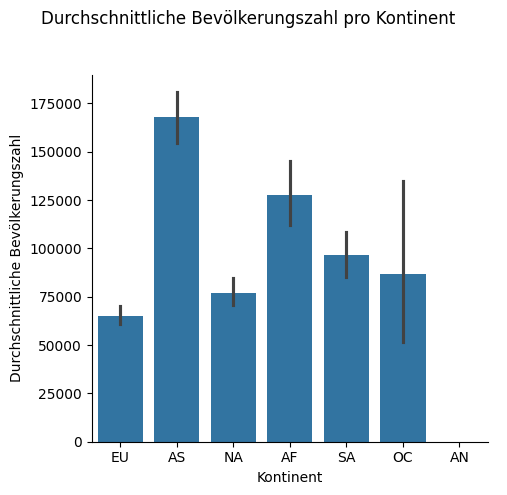

In [4]:
cat = sns.catplot(
    data=df_cities,
    x="continentcode",
    y="population",
    kind="bar",
)

cat.set_xlabels("Kontinent")
cat.set_ylabels("Durchschnittliche Bevölkerungszahl")
cat.figure.subplots_adjust(top=0.85)
cat.figure.suptitle("Durchschnittliche Bevölkerungszahl pro Kontinent")

Text(0.5, 0.98, 'Städtepositionen nach Kontinent und Bevölkerungszahl')

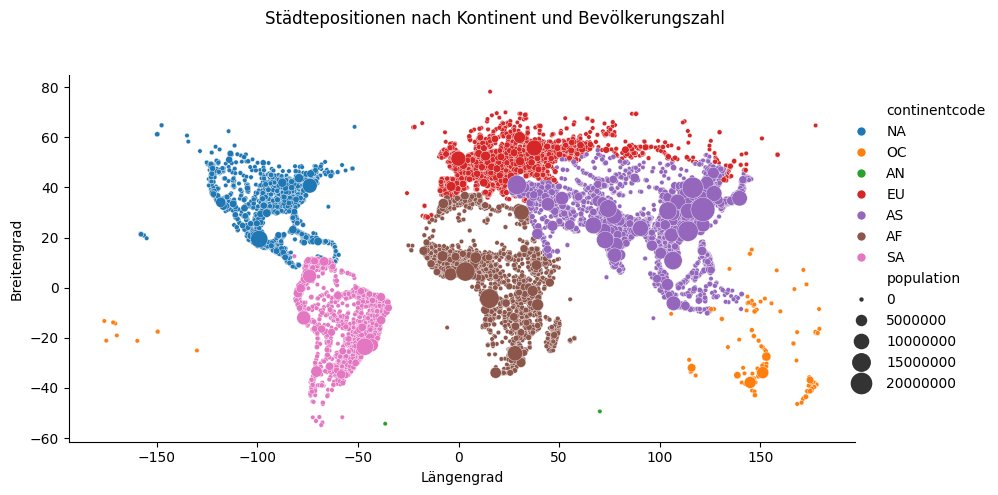

In [5]:
rel = sns.relplot(
    data=df_cities.sort_values("population", ascending=True),
    x="longitude",
    y="latitude",
    hue="continentcode",
    size="population",
    sizes=(10, 300),
    aspect=2,
)
rel.figure.set_size_inches(10, 5)
rel.set_xlabels("Längengrad")
rel.set_ylabels("Breitengrad")

rel.figure.subplots_adjust(top=0.85)
rel.figure.suptitle("Städtepositionen nach Kontinent und Bevölkerungszahl")

### Fazit

Die grafische Darstellung der durch geonamescache extrahierten Daten, wie die Verteilung der Bevölkerung über die Kontinente und die Position der Städte auf einer geographischen Karte, bietet eine direkte qualitative Einsicht:

**Bestätigung der Datenextraktion**: Bei der Darstellung der Bevölkerungszahlen pro Kontinent können wir schnell erkennen, ob die Werte innerhalb erwarteter Bereiche liegen. Anomalien könnten darauf hinweisen, dass beim Abrufen oder Zusammenführen der Daten Fehler aufgetreten sind.

**Geographische Plausibilität**: Durch die Abbildung der Städte auf einer geografischen Karte können wir überprüfen, ob die geografischen Koordinaten korrekt sind. Städte, die außerhalb ihres erwarteten geografischen Bereichs liegen, können auf fehlerhafte Daten oder eine fehlerhafte Zusammenführung hinweisen.

**Verständnis der Datenstruktur**: Das Sehen der Verteilung und der Dichte der Städte auf dem Kontinent kann helfen, ein intuitives Gefühl für die Struktur und Verteilung der Daten zu bekommen.

Zusammenfassend lässt sich sagen, dass diese visuellen Darstellungen nicht nur nützliche Informationen liefern, sondern auch dazu beitragen, die Genauigkeit und Zuverlässigkeit unseres Datenverarbeitungs- und -extraktionsprozesses zu überprüfen.


## Aufgabe 2.0

Kombiniere städtische Demografiedaten aus einer CSV-Datei mit stündlichen Wetterdaten für Städte in der Schweiz und in den Niederlanden mit einer Bevölkerung von mehr als 100.000. Erstelle daraus einen umfassenden Datensatz und visualisiere anschließend die durchschnittlichen monatlichen Temperaturen für diese Städte

### Vorgehensweise


**Datenimport und -vorbereitung**:
- Importiere den european_cities.csv Datensatz und filtere Städte in der Schweiz und in den Niederlanden mit einer Bevölkerung von mehr als 100.000 heraus.

**Wetterdaten-Integration**:
- Rufe für jede Stadt Wetterdaten ab und konvertiere sie in einen DataFrame.
- Füge städtische Informationen zum DataFrame hinzu.

**Datenvisualisierung**:
- Gruppiere die Daten nach Stadt und Monat und berechne die durchschnittliche Temperatur.
- Visualisiere die Ergebnisse in einem Boxplot.

In [6]:
BASE_URL = "https://archive-api.open-meteo.com/v1/era5"
country_1, country_2 = "CH", "NL"
city_population = 100_000

In [7]:
def get_open_meteo_hourly_data(
    latitude=42.50729,
    longitude=1.53414,
    start_date="2022-01-01",
    end_date="2022-12-31",
    api_parameter="temperature_2m",
):
    """
    Rufe stündliche Wetterdaten für gegebene Koordinaten und Zeitraum ab.

    Returns:
    - dict: Wetterdaten.
    """
    url = f"{BASE_URL}?latitude={latitude}&longitude={longitude}&start_date={
        start_date}&end_date={end_date}&hourly={api_parameter}"
    data = requests.get(url).json()
    return data


def open_meteo_data_to_dataframe(data: dict):
    """
    Konvertiere Wetterdaten in einen DataFrame und bereite ihn vor.

    Returns:
    - pd.DataFrame: DataFrame der Wetterdaten.
    """
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df["month"] = df["time"].dt.month
    df["day"] = df["time"].dt.day
    return df

In [8]:
df_cities = pd.read_csv("european_cities.csv", sep=";")
df_cities = df_cities[
    (df_cities["population"] >= city_population)
    & (
        (df_cities["countrycode"] == country_1)
        | (df_cities["countrycode"] == country_2)
    )
]

In [9]:
def get_data_for_city(city: pd.Series):
    """
    Hole Wetterdaten für eine bestimmte Stadt und füge städtische Informationen hinzu.

    Returns:
    - pd.DataFrame: Wetterdaten einer Stadt mit städtischen Informationen.
    """
    data = get_open_meteo_hourly_data(
        latitude=city["latitude"], longitude=city["longitude"]
    )
    df = open_meteo_data_to_dataframe(data)
    df["name"] = city["name"]
    df["latitude"] = city["latitude"]
    df["longitude"] = city["longitude"]
    df["countrycode"] = city["countrycode"]
    df["population"] = city["population"]
    df["continentcode"] = city["continentcode"]
    return df

In [10]:
# df_results = pd.concat(get_data_for_city(row) for _, row in df_cities.iterrows())
df_results = pd.concat(df_cities.apply(get_data_for_city, axis=1).tolist())

df_results.groupby(["name", "month"])["temperature_2m"].mean()

name              month
's-Hertogenbosch  1         4.621102
                  2         6.352232
                  3         7.197581
                  4         9.489028
                  5        14.796371
                             ...    
Zürich            8        20.608871
                  9        14.531806
                  10       13.757124
                  11        7.097639
                  12        2.157258
Name: temperature_2m, Length: 372, dtype: float64

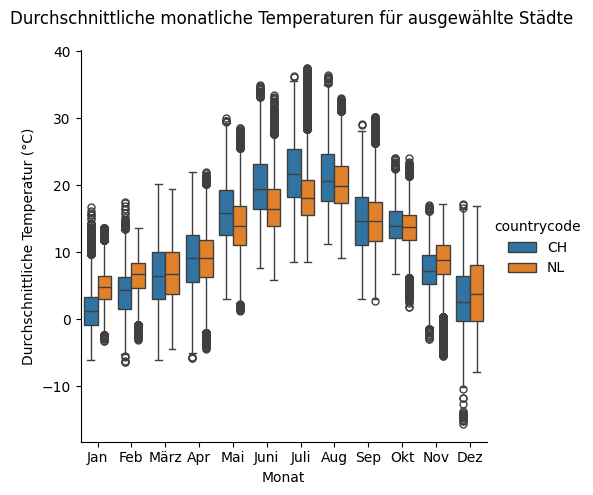

In [11]:
cat = sns.catplot(
    data=df_results,
    x="month",
    y="temperature_2m",
    hue="countrycode",
    kind="box",
)

# Für eine bessere Sichtbarkeit den Abstand vom Titel zur Plot-Oberfläche erhöhen
# passt den oberen Rand des Plots an, damit der Titel nicht überlappt
cat.figure.subplots_adjust(top=0.9)

# Titel und Achsenbeschriftungen hinzufügen
cat.figure.suptitle("Durchschnittliche monatliche Temperaturen für ausgewählte Städte")

cat.set_xlabels("Monat")
cat.set_ylabels("Durchschnittliche Temperatur (°C)")
# cat.set_axis_labels("Monat", "Durchschnittliche Temperatur (°C)")

cat.set_xticklabels(
    [
        "Jan",
        "Feb",
        "März",
        "Apr",
        "Mai",
        "Juni",
        "Juli",
        "Aug",
        "Sep",
        "Okt",
        "Nov",
        "Dez",
    ]
)

### Fazit


Der Code ermöglicht es uns, Wetterdaten für Städte in ausgewählten Ländern oder Kontinenten abzurufen, wobei eine flexible Bevölkerungsgrenze als Schwellenwert verwendet wird. Diese Daten werden dann mit demografischen Informationen kombiniert. Durch die anschließende Visualisierung der durchschnittlichen monatlichen Temperaturen können wir Einblicke in das Wetterverhalten der betreffenden Städte gewinnen und Unterschiede sowie Ähnlichkeiten zwischen ihnen erkennen. Der Code wurde dynamisch gestaltet, so dass ein einfaches Ändern der Länder, Kontinente und des Bevölkerungslimits möglich ist. Solch ein anpassbarer und datengetriebener Ansatz ist entscheidend, um fundierte Entscheidungen und Analysen in der realen Welt treffen zu können.